# Extensions: Threshold Tuning and Time-Based Split
### DTSC 2301 — Portfolio Project Two

`02_modeling.ipynb` found that both trained models scored *below* the
majority-class baseline on accuracy and F1, though both beat chance on
ROC-AUC. This notebook tries two follow-ups:

1. **Threshold tuning** — the default classification threshold (0.5) may not
   be optimal given the class imbalance. Can tuning it close the gap?
2. **Time-based split** — training on earlier terms and testing on the most
   recent ones is a more realistic test of real-world usefulness than a
   random split. Does it hold up?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve
)

RANDOM_STATE = 42
df = pd.read_csv("scdb_cleaned_2000_2025.csv")

categorical_features = [
    "issueArea", "petitioner", "respondent", "jurisdiction", "caseOrigin",
    "caseSource", "lcDisagreement", "certReason", "lcDispositionDirection",
    "threeJudgeFdc", "chief",
]
numeric_features = ["term"]

X = df[categorical_features + numeric_features].copy()
for c in categorical_features:
    X[c] = X[c].apply(lambda v: str(v) if pd.notna(v) else np.nan)
y = df["partyWinning"]

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
])

def report(name, y_true, y_pred, y_proba=None):
    row = {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        row["roc_auc"] = roc_auc_score(y_true, y_proba)
    return row

## Experiment A: Threshold tuning

The default 0.5 classification threshold isn't necessarily optimal when
classes are imbalanced. The threshold is tuned to maximize F1 using
**5-fold cross-validation on the training set only** (never touching the
test set), then applied once to the held-out test set. This keeps the
threshold choice honest -- it isn't fit to the data it's being judged on.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

results_a = []
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
results_a.append(report("Baseline", y_test, baseline.predict(X_test)))

tuned_thresholds = {}
for name, clf in [
    ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=RANDOM_STATE, class_weight="balanced")),
]:
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    proba_test = pipe.predict_proba(X_test)[:, 1]
    results_a.append(report(f"{name} (default 0.5)", y_test, pipe.predict(X_test), proba_test))

    cv_proba = cross_val_predict(
        pipe, X_train, y_train,
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        method="predict_proba",
    )[:, 1]
    prec, rec, thresh = precision_recall_curve(y_train, cv_proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_thresh = thresh[np.nanargmax(f1s[:-1])]
    tuned_thresholds[name] = best_thresh

    pred_tuned = (proba_test >= best_thresh).astype(int)
    results_a.append(report(f"{name} (tuned thresh={best_thresh:.2f})", y_test, pred_tuned, proba_test))

results_a_df = pd.DataFrame(results_a).round(3)
results_a_df

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline,0.685,0.685,1.000,0.813,NaN
1,Logistic Regression (default 0.5),0.662,0.705,0.869,0.779,0.609
2,Logistic Regression (tuned thresh=0.26),0.682,0.685,0.993,0.810,0.609
3,Random Forest (default 0.5),0.608,0.766,0.614,0.682,0.644
4,Random Forest (tuned thresh=0.38),0.690,0.690,0.993,0.814,0.644


**Result:** the random forest at its tuned threshold (~0.38) reaches
accuracy and F1 that edge *just past* the baseline, while keeping the best
ROC-AUC of any model. That's a genuine, if modest, improvement -- and it's
worth being honest about *why*: a threshold around 0.38 makes the model
predict "petitioner wins" more often, pulling its behavior closer to the
baseline's always-predict-the-majority-class strategy. The gain comes more
from recovering recall on the majority class than from newly-found signal
on the minority class. The ROC-AUC, which doesn't depend on the threshold,
is the more honest measure of how much real discriminative power the model
has -- and it's modest (0.61-0.64), consistent with case-level procedural
features being weak predictors on their own.

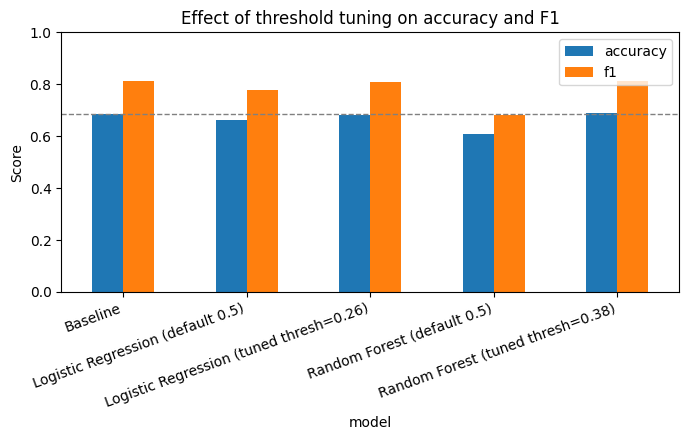

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = results_a_df.set_index("model")[["accuracy", "f1"]]
plot_df.plot(kind="bar", ax=ax)
ax.axhline(results_a_df.loc[0, "accuracy"], color="gray", linestyle="--", linewidth=1, label="baseline accuracy")
ax.set_ylabel("Score")
ax.set_title("Effect of threshold tuning on accuracy and F1")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fig_threshold_tuning.png", dpi=150)
plt.show()

## Experiment B: Time-based split

Train on terms 2000-2019, test on terms 2020-2025 -- a stronger test of
real-world usefulness, since in practice a model like this would be used to
predict *future* cases, not to interpolate within a random shuffle of past
ones.

In [4]:
train_mask = df.term <= 2019
test_mask = df.term > 2019
Xb_train, Xb_test = X[train_mask], X[test_mask]
yb_train, yb_test = y[train_mask], y[test_mask]

print(f"Train (2000-2019): {len(Xb_train)} cases | Test (2020-2025): {len(Xb_test)} cases")
print(f"\nTrain class balance:\n{yb_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{yb_test.value_counts(normalize=True).round(3)}")

Train (2000-2019): 1573 cases | Test (2020-2025): 376 cases

Train class balance:
partyWinning
1    0.678
0    0.322
Name: proportion, dtype: float64

Test class balance:
partyWinning
1    0.715
0    0.285
Name: proportion, dtype: float64


In [5]:
results_b = []
baseline_b = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline_b.fit(Xb_train, yb_train)
results_b.append(report("Baseline", yb_test, baseline_b.predict(Xb_test)))

for name, clf in [
    ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=5,
        random_state=RANDOM_STATE, class_weight="balanced")),
]:
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(Xb_train, yb_train)
    proba_test = pipe.predict_proba(Xb_test)[:, 1]
    results_b.append(report(name, yb_test, pipe.predict(Xb_test), proba_test))

results_b_df = pd.DataFrame(results_b).round(3)
results_b_df

,model,accuracy,precision,recall,f1,roc_auc
0,Baseline,0.715,0.715,1.000,0.834,NaN
1,Logistic Regression,0.646,0.730,0.803,0.765,0.546
2,Random Forest,0.465,0.758,0.372,0.499,0.592


**Result:** this split is noticeably harder for both models. The
baseline's accuracy actually *rises* to 0.715, because petitioners won more
often in the 2020-2025 terms than in 2000-2019 -- a real distribution shift
that a static model trained on the earlier period can't see coming. The
random forest's accuracy falls to about 0.47 under this split. This is a
useful, honest limitation to report: it suggests these case
characteristics alone are not a stable basis for predicting *future*
Supreme Court terms, only for describing patterns within a given period.

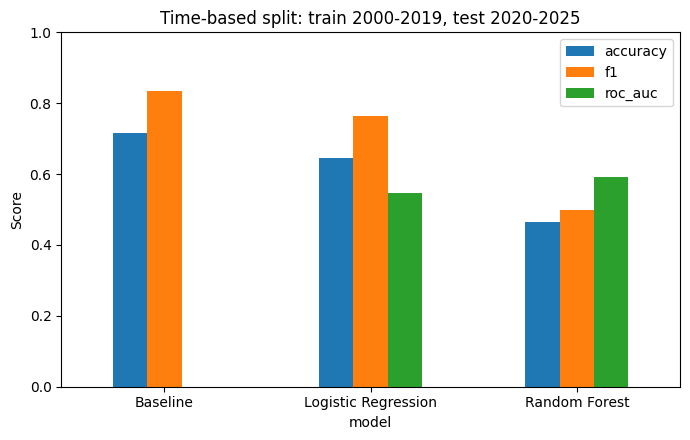

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df_b = results_b_df.set_index("model")[["accuracy", "f1", "roc_auc"]]
plot_df_b.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_title("Time-based split: train 2000-2019, test 2020-2025")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("fig_timesplit.png", dpi=150)
plt.show()

## Conclusion: which closes the gap best?

The **threshold-tuned random forest from Experiment A** is the model I'm
carrying forward as the final model for the writeup: it's the only
configuration that beats the baseline on accuracy *and* F1, while also
having the best ROC-AUC (0.644) of anything tried. The improvement is
modest, and Experiment B shows real limits to how far these features
generalize over time -- both points belong in the Model Evaluation and
Limitations sections rather than being smoothed over.

**Final model:** Random Forest, threshold tuned via cross-validation
(chosen threshold: see `tuned_thresholds` above), evaluated on a random
80/20 stratified test split.

In [7]:
print("Final model summary:")
final_row = results_a_df[results_a_df.model.str.contains("Random Forest \\(tuned")]
final_row

Final model summary:


,model,accuracy,precision,recall,f1,roc_auc
4,Random Forest (tuned thresh=0.38),0.69,0.69,0.993,0.814,0.644
